# 📊 Monte Carlo Simulation
##### Originating from statistical physics and finance, Monte Carlo methods are numerical algorithms for computing stochastic expectations via random sampling. They rely on the law of large numbers, which guarantees convergence to the true expectation, and the central limit theorem, which guarantees a convergence rate of order 

In [58]:
!pip install pandas numpy yfinance matplotlib
from IPython.display import clear_output
clear_output()
import pandas as pd, numpy as np, yfinance as yf, matplotlib.pyplot as plt
from datetime import datetime


In [59]:
# Set Ticker and date
ticker = 'TOTS3.SA'
today_str = datetime.now().strftime('%Y-%m-%d')

In [60]:
# Price Data
asset = f'{ticker}'
stock = yf.download(asset, start='2018-01-01', end=today_str, auto_adjust='False')
#stock = stock[['Close']].copy()

# Remove ticker name from columns
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)

stock['Return'] = stock['Close'].pct_change()
stock.dropna(inplace=True) # Remove NaN
stock.sort_index(ascending=True, inplace=True)
stock.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2026-05-05,32.930000,33.459999,32.540001,32.540001,7746900,0.011985
2026-05-06,33.099998,33.799999,32.980000,33.189999,5680400,0.005162
2026-05-07,36.230000,36.290001,33.110001,33.180000,9816600,0.094562
2026-05-08,35.209999,36.840000,34.959999,36.099998,6548500,-0.028153
2026-05-11,33.500000,35.000000,33.209999,34.759998,6897300,-0.048566


In [61]:
price = float(stock['Close'].iloc[-1]) # Starting Point 
mu = float(stock['Return'].mean()) # Mean Return
sigma = float(stock['Return'].std()) # Volatility
sigma_perc = round(sigma * 100, 2)

print(f"Diary Vol.: {sigma_perc}%")
print(f"68% chance (1 sigma): -{sigma_perc}% and +{sigma_perc}% relative to the average.")
print(f"95% chance (2 sigmas): -{round(sigma_perc * 2, 2)}% e +{round(sigma_perc * 2, 2)}% relative to the average.")

Diary Vol.: 2.43%
68% chance (1 sigma): -2.43% and +2.43% relative to the average.
95% chance (2 sigmas): -4.86% e +4.86% relative to the average.


C:\Users\vinicius.bernardino\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


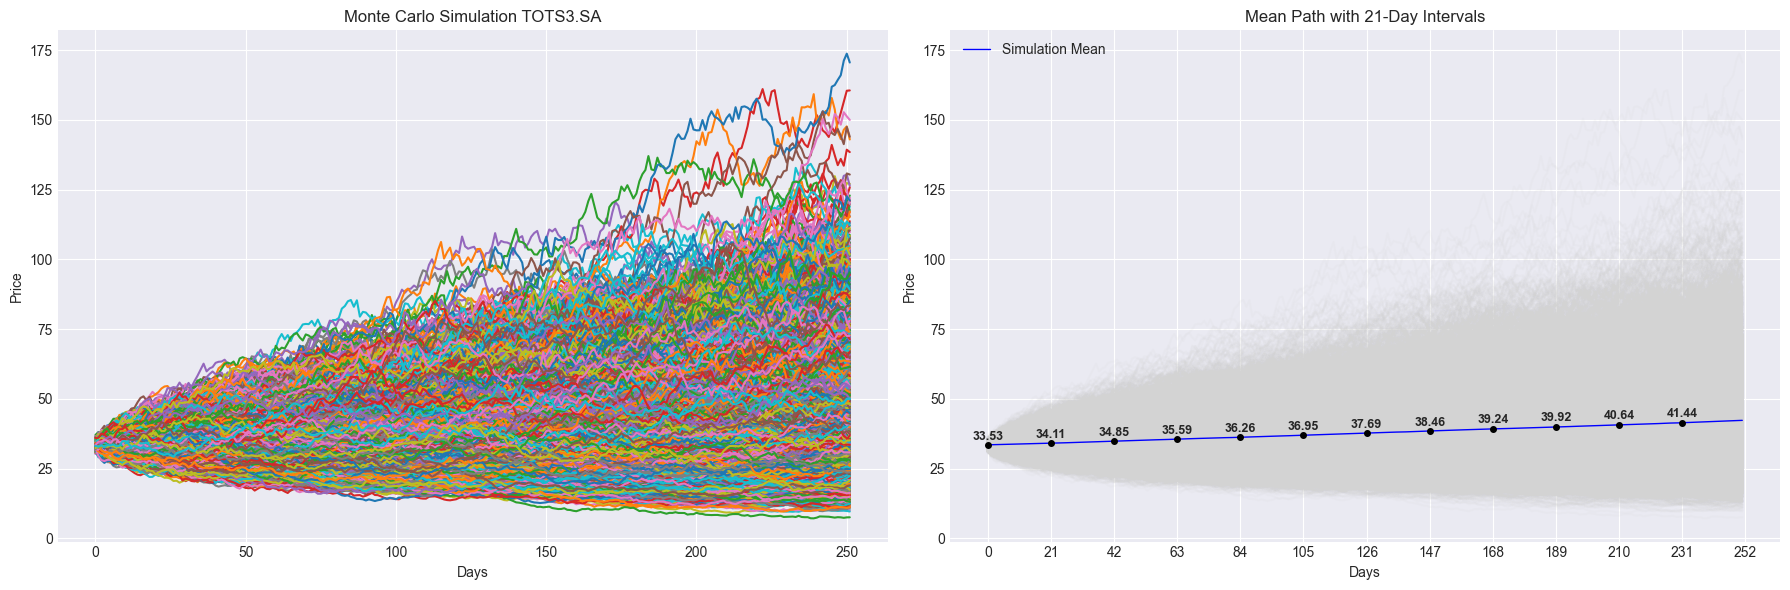

In [ ]:
days = 252
sim = 10000 # Law of Large Numbers
paths = np.zeros((days, sim))

for i in range(sim):
    prices = [price]
    for j in range(days):
        shock = np.random.normal(mu, sigma) # Simulates market uncertainty
        next_price = prices[-1] * (1 + shock)
        prices.append(float(next_price))
    paths[:, i] = prices[1:]

mean_path = np.mean(paths, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(paths)
ax1.set_xlabel('Days')
ax1.set_ylabel('Price')
ax1.set_title(f'Monte Carlo Simulation {ticker}')

ax2.plot(paths, color='lightgray', alpha=0.1)
ax2.plot(mean_path, color='blue', linewidth=1, label='Simulation Mean')

interval = 21
for day in range(0, days, interval):
    val_at_day = mean_path[day]
    ax2.plot(day, val_at_day, 'ko', markersize=4)
    ax2.text(day, val_at_day * 1.05, f'{val_at_day:.2f}', fontsize=9, fontweight='bold', ha='center')

ax2.set_xticks(range(0, days + 1, interval))
ax2.set_xlabel('Days')
ax2.set_ylabel('Price')
ax2.set_title(f'Mean Path with 21-Day Intervals')
ax2.legend()

plt.tight_layout()
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()

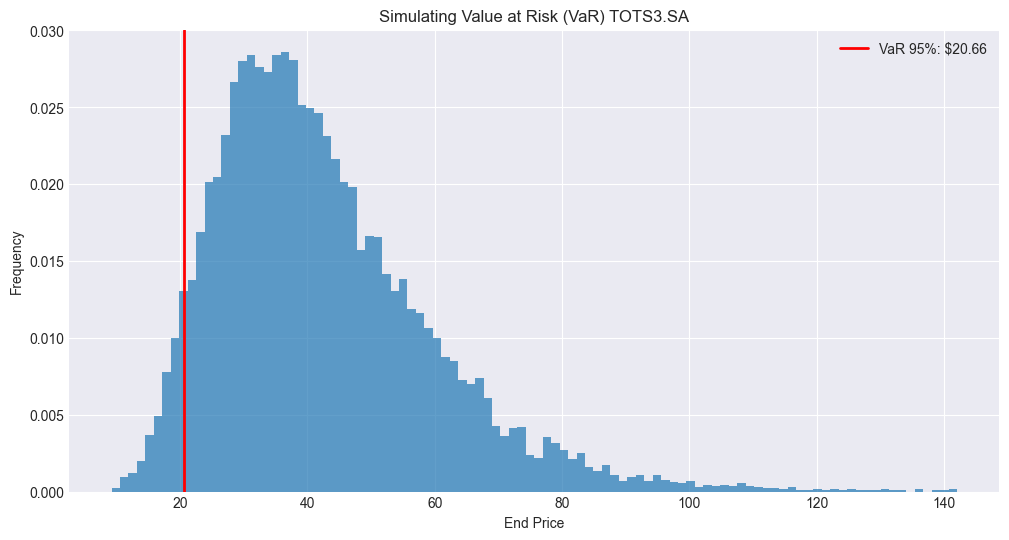

95% chance that price is > $20.66


In [86]:
end_prices = paths[-1, :]

var_95 = np.percentile(end_prices, 5)

plt.figure(figsize=(12,6))
plt.hist(end_prices, bins=100, alpha=0.7, density=True)

plt.axvline(var_95, color='r', linestyle='-', linewidth=2, label=f'VaR 95%: ${var_95:.2f}')

plt.title(f"Simulating Value at Risk (VaR) {ticker}")
plt.xlabel("End Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"95% chance that price is > ${var_95:.2f}")


In [74]:
range_min = min(end_prices)
range_max = max(end_prices)
num_bins = 25

bins = np.linspace(range_min, range_max, num_bins)
hist, _ = np.histogram(end_prices, bins=bins)
percentages = (hist / len(end_prices)) * 100

print("Prob Distribution Table\n")
for i in range(len(bins)-1):
    print(f"Price Range ${bins[i]:.2f} - ${bins[i+1]:.2f}: {percentages[i]:.2f}%")

Prob Distribution Table

Price Range $9.25 - $14.78: 0.69%
Price Range $14.78 - $20.32: 3.96%
Price Range $20.32 - $25.85: 9.24%
Price Range $25.85 - $31.38: 14.16%
Price Range $31.38 - $36.91: 15.46%
Price Range $36.91 - $42.44: 14.38%
Price Range $42.44 - $47.98: 11.61%
Price Range $47.98 - $53.51: 8.52%
Price Range $53.51 - $59.04: 6.87%
Price Range $59.04 - $64.57: 5.01%
Price Range $64.57 - $70.10: 3.48%
Price Range $70.10 - $75.63: 2.01%
Price Range $75.63 - $81.17: 1.57%
Price Range $81.17 - $86.70: 1.05%
Price Range $86.70 - $92.23: 0.59%
Price Range $92.23 - $97.76: 0.42%
Price Range $97.76 - $103.29: 0.29%
Price Range $103.29 - $108.82: 0.25%
Price Range $108.82 - $114.36: 0.15%
Price Range $114.36 - $119.89: 0.10%
Price Range $119.89 - $125.42: 0.04%
Price Range $125.42 - $130.95: 0.06%
Price Range $130.95 - $136.48: 0.05%
Price Range $136.48 - $142.01: 0.04%
